# Emotion Classification

## Import Packages

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset, load_dataset
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

import warnings
warnings.filterwarnings('ignore')

## Data Loading

In [ ]:
ds = load_dataset("dair-ai/emotion", "unsplit")
train_val = ds["train"].train_test_split(test_size=0.1, seed=42, stratify_by_column="label")
train_ds = train_val["train"]
val_ds = train_val["test"]

README.md: 0.00B [00:00, ?B/s]

unsplit/train-00000-of-00001.parquet:   0%|          | 0.00/26.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/416809 [00:00<?, ? examples/s]

## Model Training

In [ ]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_ds = train_ds.map(tokenize_function, batched=True)
val_ds = val_ds.map(tokenize_function, batched=True)

Map:   0%|          | 0/375128 [00:00<?, ? examples/s]

Map:   0%|          | 0/41681 [00:00<?, ? examples/s]

In [ ]:
train_ds = train_ds.remove_columns(["text"])
val_ds = val_ds.remove_columns(["text"])

train_ds.set_format("torch")
val_ds.set_format("torch")

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,0.183319,0.178197
2,0.171169,0.182308
3,0.151083,0.188120


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=35169, training_loss=0.19831839114602978, metrics={'train_runtime': 8436.0941, 'train_samples_per_second': 133.401, 'train_steps_per_second': 4.169, 'total_flos': 3.727183131342029e+16, 'train_loss': 0.19831839114602978, 'epoch': 3.0})

In [ ]:
trainer.save_model("./emotion_model")
tokenizer.save_pretrained("./emotion_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./emotion_model/tokenizer_config.json', './emotion_model/tokenizer.json')

## Model Evaluation

In [ ]:
model_path = "/kaggle/working/emotion_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    accuracy = accuracy_score(y_true=labels, y_pred=predictions)
    f1 = f1_score(y_true=labels, y_pred=predictions, average="weighted")
    
    return {
        "accuracy": accuracy,
        "f1": f1
    }

In [ ]:
eval_args = TrainingArguments(
    output_dir="./eval_results",
    per_device_eval_batch_size=16,
    report_to="none" 
)

trainer = Trainer(
    model=model,
    args=eval_args,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

print("Generating predictions and calculating metrics...")
prediction_output = trainer.predict(val_ds)

print("\n--- Evaluation Results ---")
for key, value in prediction_output.metrics.items():
    print(f"{key}: {value:.4f}")

Generating predictions and calculating metrics...



--- Evaluation Results ---
test_loss: 0.1782
test_accuracy: 0.9421
test_f1: 0.9437
test_runtime: 101.3919
test_samples_per_second: 411.0880
test_steps_per_second: 12.8510


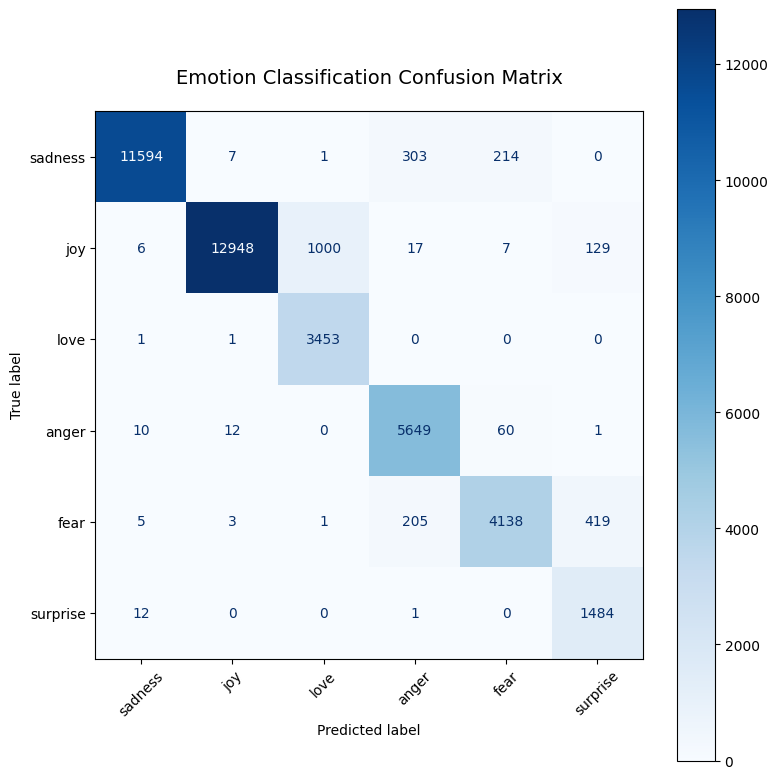

In [ ]:
y_preds = np.argmax(prediction_output.predictions, axis=1)
y_true = prediction_output.label_ids
label_names = ds["train"].features["label"].names

cm = confusion_matrix(y_true, y_preds)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)

plt.title("Emotion Classification Confusion Matrix", pad=20, fontsize=14)
plt.tight_layout()
plt.show()